# Homework 0

Joshua Ng

### 1. Setting Up Your Python Environment
Environment is "mse298hw0"

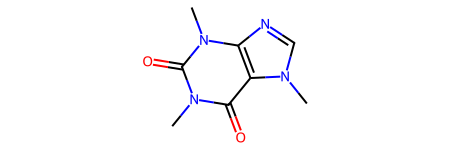

In [1]:
from rdkit import Chem
mol = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
mol

### 2.1 Reviewing Vector Spaces Linear Algebra, Linear Independence of Vectors

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.colors as colors
from scipy.ndimage import minimum_filter
np.random.seed

Vectors_2_0 = np.array(
    [np.random.normal(0, 1, 4), 
     np.random.normal(0, 1, 4), 
     np.random.normal(0, 1, 4),
     np.random.normal(0, 1, 4)]
    # [[1,0,0,0],
    # [0,1,0,0],
    # [0,0,1,0],
    # [0,0,0,1]]
)

rank = np.linalg.matrix_rank(Vectors_2_0)
if rank == Vectors_2_0.shape[0]:
    # If the rank of the matrix is equal to the size of the matrix, then it must be linearly
    # independent. 
    eigenvalues, eigenvectors = np.linalg.eig(Vectors_2_0)
    print("The vectors are linearly independent")
    # Printing Eigenvalue, Eigenvector pairs
    for i in range(rank):
        print(f"Eigenvalue: {eigenvalues[i]}\nEigenvector: {eigenvectors[i]}\n")
else:
    print(f"Degenerate with Rank: {rank}")
  
Vectors_tr = Vectors_2_0.T
dot_products = Vectors_2_0 @ Vectors_tr
off_diagonal = dot_products - np.diag(np.diag(dot_products))
if np.allclose(off_diagonal, 0) == True:
    # Each index represents a dot product between the matrix of the row and product
    # The diagnols are zero'ed so the whole matrix should be zero
    print("The vectors are orthogonal")
else:
    
    print("The vectors are not orthogonal")



The vectors are linearly independent
Eigenvalue: (1.8208790539652107+0.6883633267450948j)
Eigenvector: [ 0.81203828+0.j  0.81203828-0.j -0.64744145+0.j  0.72898457+0.j]

Eigenvalue: (1.8208790539652107-0.6883633267450948j)
Eigenvector: [ 0.28595338+0.24634661j  0.28595338-0.24634661j  0.24709726+0.j
 -0.28691431+0.j        ]

Eigenvalue: (-1.2658442239681105+0j)
Eigenvector: [-0.10176924-0.05347555j -0.10176924+0.05347555j -0.49720792+0.j
  0.30935402+0.j        ]

Eigenvalue: (-0.579000448167243+0j)
Eigenvector: [ 0.3916972 +0.17746699j  0.3916972 -0.17746699j -0.52206015+0.j
  0.53903782+0.j        ]

The vectors are not orthogonal


In [ ]:
# Running the loop 1000 times
num_linindep = 0

for i in range(1000):
    Vectors_2_1 = np.array(
    [np.random.normal(0, 1, 4), 
     np.random.normal(0, 1, 4), 
     np.random.normal(0, 1, 4),
     np.random.normal(0, 1, 4)])

    rank = np.linalg.matrix_rank(Vectors_2_1)
    if rank == Vectors_2_1.shape[0]:
        num_linindep += 1

print(num_linindep)

1000


Almost all of the vectors are linearly independent because for there to be a dependent variable the sample from the gaussian distribtuion must be exactly a multiple of one another, which since this is a 4D space, means that 4 pairs of random numbers all are multiples of one another. If we relax the constraint for linear independence it would be much more likely to have some dependence.

### 2.2 Orthagonality in Higher Dimensions

In [5]:
# 3D space
np.random.seed
covariance_matrix = np.array([[1,0,0], [0,1,0], [0,0,1]])
vectors_2_2 = np.random.multivariate_normal([0,0,0], covariance_matrix, size = 1000)
norms = np.linalg.norm(vectors_2_2, axis=1, keepdims=True)
vectors_2_2 = vectors_2_2/norms

Vectors_tr_2 = vectors_2_2.T
dot_products_2 = vectors_2_2 @ Vectors_tr_2
total_count = 0
count_orthogonal = 0

for i in range(dot_products.shape[0]):
    for j in range(i+1, dot_products.shape[0]):
        total_count += 1
        if abs(dot_products[i,j]) < 10**-5:
            count_orthogonal += 1
print(f"""There are {count_orthogonal} orthogonal vectors from {total_count} vector pairs, corresponding to {round(count_orthogonal/total_count*100, 7)}% of vector pairs being orthogonal.""")

There are 0 orthogonal vectors from 6 vector pairs, corresponding to 0.0% of vector pairs being orthogonal.


In [6]:
# R^n where n is between 3 and 128
def orthogonal_n(dimension, epsilon):
    np.random.seed
    covariance_matrix = np.identity(dimension)
    mean = [0 for i in range(dimension)]
    vectors_2_2 = np.random.multivariate_normal(mean, covariance_matrix, size = 1000)
    norms = np.linalg.norm(vectors_2_2, axis=1, keepdims=True)
    vectors_2_2 = vectors_2_2/norms

    Vectors_tr = vectors_2_2.T
    dot_products = vectors_2_2 @ Vectors_tr
    total_count = 0
    count_orthogonal = 0

    for i in range(dot_products.shape[0]):
        for j in range(i+1, dot_products.shape[0]):
            total_count += 1
            if abs(dot_products[i,j]) < epsilon:
                count_orthogonal += 1
    
    return round(count_orthogonal/total_count*100, 7)

In [7]:
# Computationally expensive block with epsilon  = 10**-5, separated
y_values_1 = [orthogonal_n(i,10**-5) for i in range(3, 128)]
x_values = [i for i in range(3, 128)]

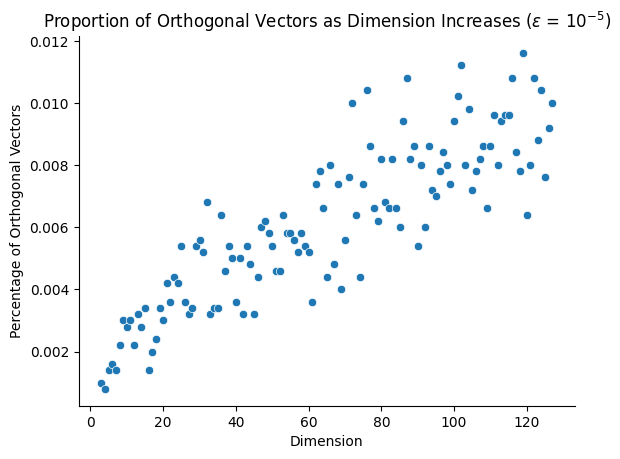

In [8]:
# Plotting the case where: epsilon = 10**-5 
sns.scatterplot(x = x_values, y = y_values_1)
sns.despine()
plt.xlabel("Dimension")
plt.ylabel("Percentage of Orthogonal Vectors")
plt.title(r"Proportion of Orthogonal Vectors as Dimension Increases ($\epsilon$ = $10^{-5}$)")
plt.show()

In [9]:
# Computationally expensive block with epsilon  = 10**-2, separated
y_values_2 = [orthogonal_n(i,10**-2) for i in range(3, 128)]

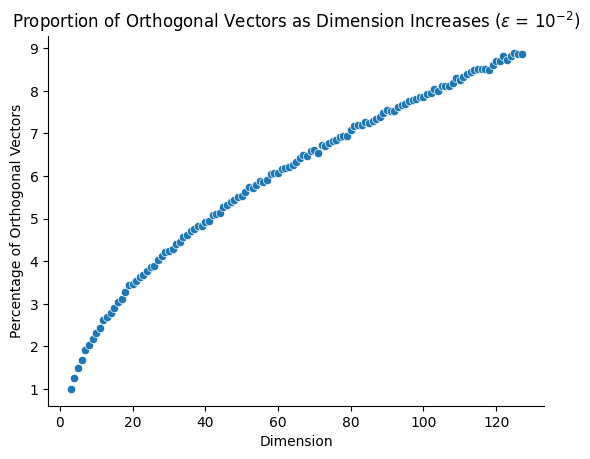

In [10]:
# Plotting the case where: epsilon = 10**-2
sns.scatterplot(x = x_values, y = y_values_2)
sns.despine()
plt.xlabel("Dimension")
plt.ylabel("Percentage of Orthogonal Vectors")
plt.title(r"Proportion of Orthogonal Vectors as Dimension Increases ($\epsilon$ = $10^{-2}$)")
plt.show()

In [11]:
#Extreme Case with 10,000 vectors
pairs_orthogonal_2048 = sum([orthogonal_n(2048, 10**-2) for i in range(10)])/10

In [12]:
print(f"There are {pairs_orthogonal_2048}% of pairs of orthogonal vectors in 2048 dimensions with ε = 1e-2.")

There are 34.86968969% of pairs of orthogonal vectors in 2048 dimensions with ε = 1e-2.


As the dimension of the vectors increases, there are more orthogonal pairs of vectors. 

A heuristic explanation from this is that the equator of the unit "sphere" of an arbitrary dimension size increases faster than the rest of the other regions respect to the pole of the sphere, meaning that most of the vectors in higher dimensions lie on or near the orthogonal plane by random chance compared to lower dimensions. Since our program randomly samples normalized vectors from a gaussian distribution, the theoretical probability a vector lies in a certain range of values is equal to the area encompassed by the bounds on a unit "sphere" of n-dimensions.This can be imagined by the 2D -> 3D transition, where if the vectors on a 2D "sphere" are shown, there are only 2 regions near 0 and pi radians which correspond to valid orthogonal vectors, but the 3D sphere is the rotation of the 2D sphere, and since the equator is furthest from the poles, the vectors near the equator now cover more of an area on the unit sphere in the 3D case compared to the 2D case. As the dimensions increase the equator takes up more and more of the percentage of the surface area by this rotation effect about the poles, and therefore there are more orthogonal vectors.

### 3 Data loading and simple analysis

In [13]:
# Loading Data in it's own cell so it's not reloaded
df = pd.read_csv("https://gitfront.io/r/user-4084034/v8tPPiVnFLtE/ml4mat-25w-public/raw/lectures/01-DataScience/data/ptable.csv")
df.head()

,AtomicNumber,Element,Symbol,AtomicMass,NumberofNeutrons,NumberofProtons,NumberofElectrons,Period,Group,Phase,...,FirstIonization,Density,MeltingPoint,BoilingPoint,NumberOfIsotopes,Discoverer,Year,SpecificHeat,NumberofShells,NumberofValence
0,1,Hydrogen,H,1.007,0,1,1,1,1.0,gas,...,13.5984,0.000090,14.175,20.28,3.0,Cavendish,1766.0,14.304,1,1.0
1,2,Helium,He,4.002,2,2,2,1,18.0,gas,...,24.5874,0.000179,NaN,4.22,5.0,Janssen,1868.0,5.193,1,NaN
2,3,Lithium,Li,6.941,4,3,3,2,1.0,solid,...,5.3917,0.534000,453.850,1615.00,5.0,Arfvedson,1817.0,3.582,2,1.0
3,4,Beryllium,Be,9.012,5,4,4,2,2.0,solid,...,9.3227,1.850000,1560.150,2742.00,6.0,Vaulquelin,1798.0,1.825,2,2.0
4,5,Boron,B,10.811,6,5,5,2,13.0,solid,...,8.2980,2.340000,2573.150,4200.00,6.0,Gay-Lussac,1808.0,1.026,2,3.0


In [14]:
# print(df["MetallicProperty"].head())
df["MassKg"] = (df["NumberofNeutrons"]+df["NumberofProtons"])*1.67*10**-27 + df["NumberofElectrons"]*9.11*10**-31
art_df = df.loc[df["Natural"] == "no"]
print("3.1)")
print(df["MassKg"].head())

print(f"\n\n3.2)\nThe average year of discovery for artificial elements is {math.floor(art_df["Year"].mean())}.")

print(f"\n\n3.3)\n{df.groupby("MetallicProperty")["Electronegativity"].median()}")

df_clean = df.dropna()
print(f"\n\n3.4)\nThere are {len(df_clean)} rows in the cleaned dataframe.")

3.1)
0    1.670911e-27
1    6.681822e-27
2    1.169273e-26
3    1.503364e-26
4    1.837455e-26
Name: MassKg, dtype: float64


3.2)
The average year of discovery for artificial elements is 1971.


3.3)
MetallicProperty
metal        1.31
metalloid    2.04
nonmetal     2.62
Name: Electronegativity, dtype: float64


3.4)
There are 29 rows in the cleaned dataframe.


## 4 Himmelblau's Function

### 4.1)

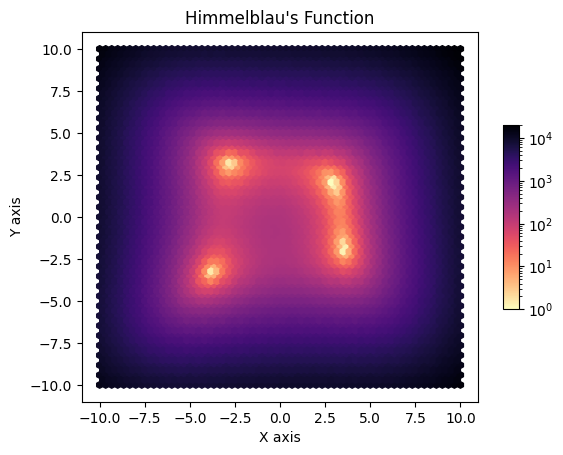

In [86]:
x_values = np.linspace(-10,10, 101)
y_values = np.linspace(-10,10, 101)
X, Y = np.meshgrid(x_values, y_values)
z_values = (X**2 + Y -11)**2 + (X + Y**2 - 7)**2
plt.close("all")
fig = plt.figure()
ax = fig.add_subplot(111)

surface = ax.hexbin(X.flatten(), Y.flatten(), z_values.flatten(), norm=colors.LogNorm(vmin=1, vmax=z_values.max()), cmap = 'magma_r', gridsize=60)
ax.set_title("Himmelblau's Function")
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_label("Z-value")
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=12)
plt.show()

### 4.2)

In [60]:
data_min = minimum_filter(z_values, size=3)
is_minima = (z_values == data_min)
y_idxs, x_idxs = np.where(is_minima)


min_x = x_values[x_idxs]
min_y = y_values[y_idxs]
min_z = z_values[y_idxs, x_idxs]

print(f"Found {len(min_z)} potential minima.")
for i in range(len(min_x)):
    print(f"({round(min_x[i], 3)}, {round(min_y[i], 3)}, {round(min_z[i], 3)})")


Found 4 potential minima.
(-3.8, -3.2, 0.371)
(3.6, -1.8, 0.051)
(3.0, 2.0, 0.0)
(-2.8, 3.2, 0.195)


### 4.3)

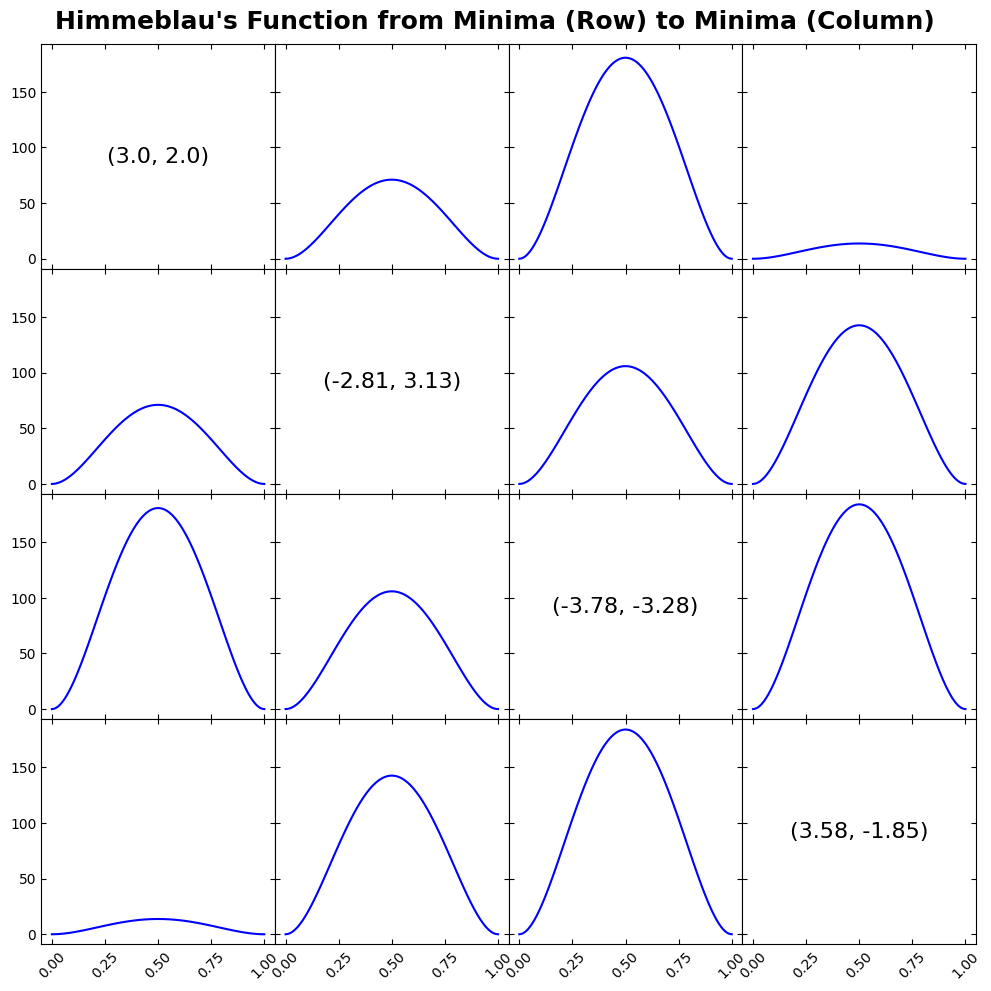

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_min_2_min(m1, m2):
    datapoints = 100
    x_vals = np.linspace(0, 1, datapoints)
    y_vals = []
    for t in x_vals:
        curr_x = m1[0] + t * (m2[0] - m1[0])
        curr_y = m1[1] + t * (m2[1] - m1[1])
        val = (curr_x**2 + curr_y - 11)**2 + (curr_x + curr_y**2 - 7)**2
        y_vals.append(val)
    return x_vals, y_vals

plt.close('all')

fig, axes = plt.subplots(4, 4, figsize=(10, 10), sharex=True, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0})

labels = [f"({round(min_x[i], 2)}, {round(min_y[i], 2)})" for i in range(4)]

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        
        if i == j:
            ax.text(0.5, 0.5, labels[i], transform=ax.transAxes, 
                    ha='center', va='center', fontsize=16, color='k')
        else:
            xv, yv = plot_min_2_min([min_x[i], min_y[i]], [min_x[j], min_y[j]])
            ax.plot(xv, yv, color='b')

        ax.tick_params(direction='in', top=True, right=True)

        if j != 0:
            ax.tick_params(axis='y', labelleft=False)

        if i != 3:
            ax.tick_params(axis='x', labelbottom=False)
        else:
            ax.tick_params(axis='x', labelrotation = 45)

fig.suptitle("Himmeblau's Function from Minima (Row) to Minima (Column)", fontsize=18, fontweight = "bold")
plt.tight_layout() 
plt.show()

### 4.4)